In [ ]:
import pandas as pd #Used to read and handle dataset (CSV file).
from sklearn.model_selection import train_test_split #Used to split data into training and testing.
from sklearn.linear_model import LinearRegression #This is the machine learning algorithm we use to predict house prices.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score #Used to check how good our model is.

In [4]:
data = pd.read_csv(r"C:\Users\mphar\OneDrive\Desktop\Python\MODEL TRAINING\Housing.csv")
data.head(7)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
#One hot coding = Machine learning understands only numbers.So we convert text → numbers.
data = pd.get_dummies(data, drop_first=True)

In [ ]:
X = data.drop("price", axis=1) #Input features (area, bedrooms, bathrooms etc.)
y = data["price"]       #Output predict values (price)      

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed ✅")

Model Training Completed ✅


In [ ]:
#It will predicts prices for test data.
y_pred = model.predict(X_test)

In [ ]:
import numpy as np
#Average error between actual and predicted price.
mae = mean_absolute_error(y_test, y_pred)
#Penalizes bigger errors more.
mse = mean_squared_error(y_test, y_pred)
#Same unit as price (easy to understand).
rmse = np.sqrt(mse)
#R² Score tells how well model fits.
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.4039201637
MSE: 1754318687330.6628
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


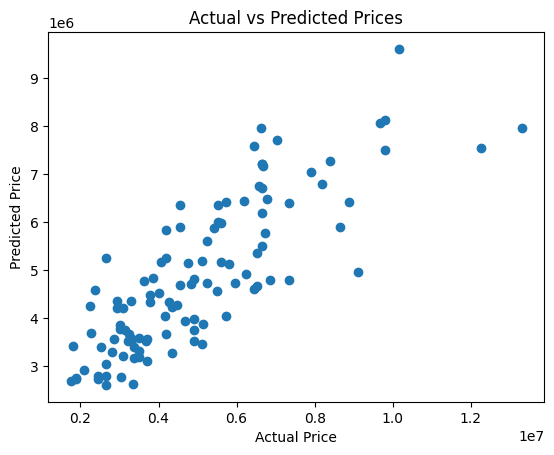

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()